# EJEMPLO BASICO DE USO DE TENSORFLOW PARA CREAR UNA RED NEURONAL ARTIFICIAL

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [20]:
# Semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# 1. Dataset puerta lógica AND

In [21]:
df_and = pd.DataFrame({
    "x1": [0, 0, 1, 1],
    "x2": [0, 1, 0, 1],
    "y":  [0, 0, 0, 1]
})

X_and = df_and[["x1", "x2"]].values.astype("float32")
y_and = df_and["y"].values.astype("float32")

df_and

,x1,x2,y
0,0,0,0
1,0,1,0
2,1,0,0
3,1,1,1


# 2. Modelo neuronal para AND

In [23]:
model_and = Sequential([
    Dense(
        1,
        input_shape=(2,),
        activation="sigmoid",
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42),
        bias_initializer="zeros"
    )
])

model_and.compile(
    optimizer=Adam(learning_rate=0.1),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_and = model_and.fit(
    X_and,
    y_and,
    epochs=20,
    verbose=0
)

In [24]:
pred_probs = model_and.predict(X_and)
pred_classes = (pred_probs >= 0.5).astype(int)

df_and["prediccion"] = pred_classes.flatten()

df_and

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


,x1,x2,y,prediccion
0,0,0,0,0
1,0,1,0,0
2,1,0,0,0
3,1,1,1,1


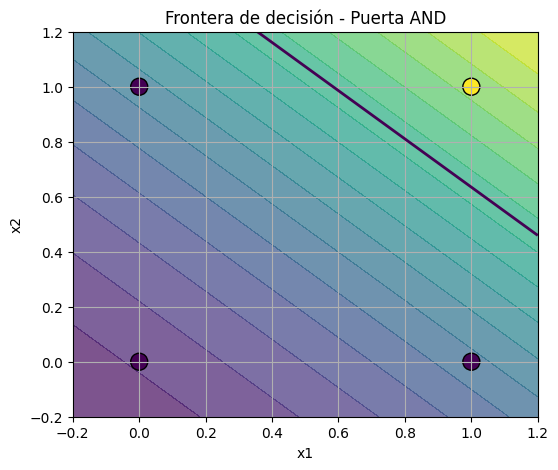

In [26]:
xx, yy = np.meshgrid(
    np.linspace(-0.2, 1.2, 100),
    np.linspace(-0.2, 1.2, 100)
)

grid = np.c_[xx.ravel(), yy.ravel()]
probs = model_and.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, probs, levels=20, alpha=0.7)
plt.contour(xx, yy, probs, levels=[0.5], linewidths=2)

plt.scatter(X_and[:, 0], X_and[:, 1], c=y_and, s=150, edgecolors="black")

plt.title("Frontera de decisión - Puerta AND")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()